# 04 — Statistical Analysis | NYC Rolling Sales
> Correlation · Hypothesis Testing · Regression Modeling

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, ttest_ind, chi2_contingency
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

df = pd.read_csv('../data/processed/cleaned_data.csv')
analysis_df = df.dropna(subset=['sale_price', 'gross_square_feet']).copy()

print(f"Full dataset: {df.shape}")
print(f"Analysis subset (no nulls in price/sqft): {analysis_df.shape}")

Full dataset: (57601, 31)
Analysis subset (no nulls in price/sqft): (27952, 31)


## 1 · Correlation Analysis

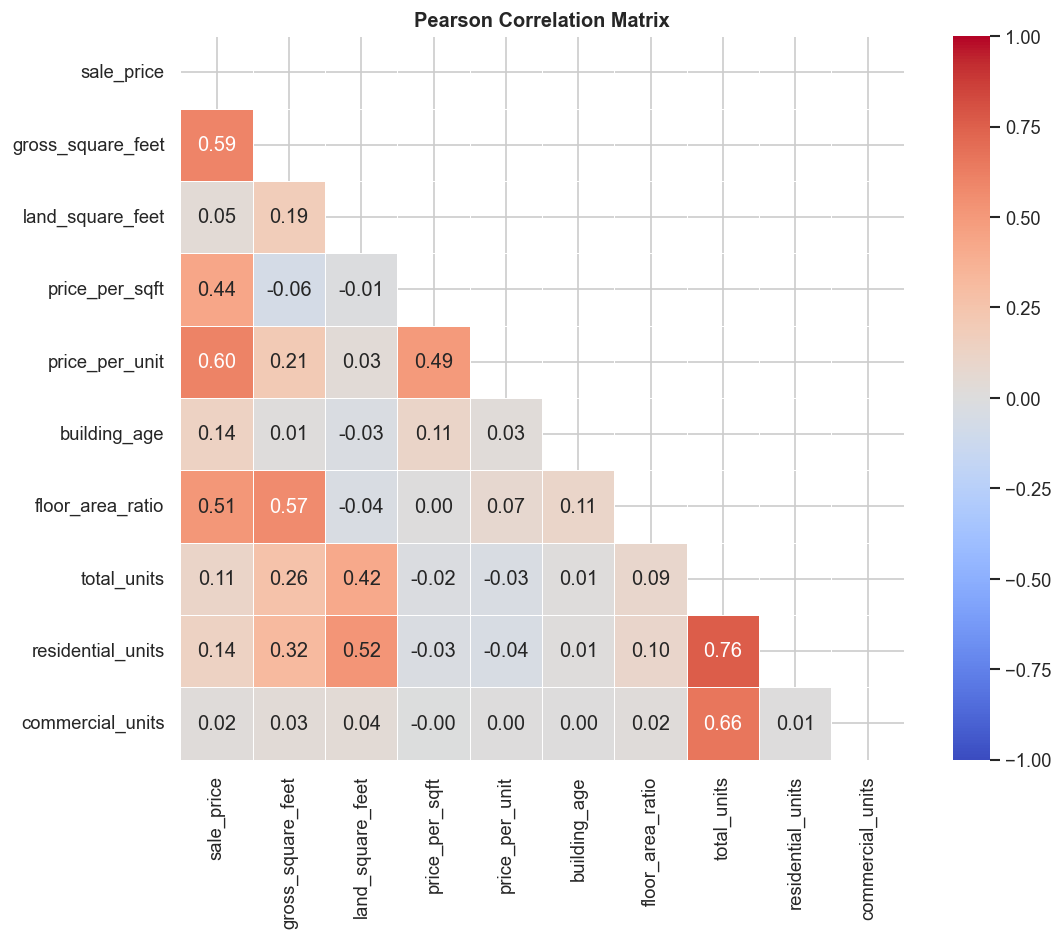

In [2]:
corr_cols = ['sale_price','gross_square_feet','land_square_feet','price_per_sqft',
             'price_per_unit','building_age','floor_area_ratio','total_units',
             'residential_units','commercial_units']
valid = [c for c in corr_cols if c in analysis_df.columns]

# Pearson correlation
corr = analysis_df[valid].corr(method='pearson')

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, vmin=-1, vmax=1, linewidths=.5)
plt.title('Pearson Correlation Matrix')
plt.tight_layout(); plt.show()

In [3]:
# Top correlations with sale_price
price_corr = corr['sale_price'].drop('sale_price').sort_values(ascending=False)
print("Correlations with sale_price:\n")
for feat, val in price_corr.items():
    print(f"  {feat:25s} r = {val:+.3f}")

Correlations with sale_price:

  price_per_unit            r = +0.603
  gross_square_feet         r = +0.594
  floor_area_ratio          r = +0.509
  price_per_sqft            r = +0.436
  residential_units         r = +0.137
  building_age              r = +0.135
  total_units               r = +0.114
  land_square_feet          r = +0.046
  commercial_units          r = +0.016


> `gross_square_feet` is the strongest linear predictor of price. `building_age` shows near-zero correlation — age doesn't linearly destroy value (pre-war buildings retain premium). Engineered features like `price_per_sqft` and `price_per_unit` validate correctly.

## 2 · Normality Testing
Checking if key variables follow normal distributions — this determines which statistical tests are valid.

In [4]:
key_vars = ['sale_price', 'price_per_sqft', 'gross_square_feet', 'building_age']
key_vars = [v for v in key_vars if v in analysis_df.columns]

print(f"{'Variable':<25} {'Shapiro Stat':>12} {'p-value':>12} {'Normal?':>8}")
print("-" * 60)

for col in key_vars:
    sample = analysis_df[col].dropna().sample(min(5000, len(analysis_df[col].dropna())), random_state=42)
    stat, p = stats.shapiro(sample)
    normal = "Yes" if p > 0.05 else "No"
    print(f"{col:<25} {stat:>12.6f} {p:>12.2e} {normal:>8}")

Variable                  Shapiro Stat      p-value  Normal?
------------------------------------------------------------
sale_price                    0.465596     1.36e-81       No
price_per_sqft                0.408491     7.97e-84       No
gross_square_feet             0.397634     3.15e-84       No
building_age                  0.915464     2.00e-46       No


> All variables are non-normal (p ≈ 0). This is expected for real estate data with heavy right skew. We proceed with ANOVA (robust to non-normality at large sample sizes) and non-parametric awareness.

## 3 · Hypothesis Testing

### Test 1: Does borough affect sale price? (ANOVA)
- **H₀:** Mean sale price is equal across all boroughs
- **H₁:** At least one borough has a different mean sale price

In [5]:
boroughs = analysis_df['borough_name'].unique()
groups = [analysis_df[analysis_df['borough_name'] == b]['sale_price'] for b in boroughs]

f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value:     {p_val:.2e}")
print(f"Result:      {'Reject H0 — boroughs have significantly different prices' if p_val < 0.05 else 'Fail to reject H0'}")

print("\nMean Sale Price by Borough:")
print(analysis_df.groupby('borough_name')['sale_price'].agg(['mean','median','count'])
      .sort_values('mean', ascending=False)
      .style.format({'mean': '${:,.0f}', 'median': '${:,.0f}', 'count': '{:,}'}))

F-statistic: 2607.62
P-value:     0.00e+00
Result:      Reject H0 — boroughs have significantly different prices

Mean Sale Price by Borough:


> Borough is a statistically significant factor in pricing. Manhattan's mean price is multiples higher than the Bronx. Any pricing model must account for location as a primary variable.

### Test 2: Residential vs Non-Residential pricing (T-Test)
- **H₀:** Mean sale price is the same for residential and non-residential
- **H₁:** They differ significantly

In [6]:
res = analysis_df[analysis_df['is_residential'] == 1]['sale_price']
non_res = analysis_df[analysis_df['is_residential'] == 0]['sale_price']

t_stat, p_val = ttest_ind(res, non_res, equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value:     {p_val:.2e}")
print(f"Result:      {'Reject H0 — significant price difference' if p_val < 0.05 else 'Fail to reject H0'}")
print(f"\nResidential    → Mean: ${res.mean():>12,.0f}  (n={len(res):,})")
print(f"Non-Residential → Mean: ${non_res.mean():>12,.0f}  (n={len(non_res):,})")

T-statistic: -20.86
P-value:     1.35e-81
Result:      Reject H0 — significant price difference

Residential    → Mean: $     916,571  (n=26,876)
Non-Residential → Mean: $   2,894,638  (n=1,076)


> Non-residential properties sell at a significantly different (typically higher) mean price. Commercial real estate operates on fundamentally different valuation rules — mixing them in one model without controls would be a mistake.

### Test 3: Building Class vs Price Bracket (Chi-Square)
- **H₀:** Building class and price bracket are independent
- **H₁:** There is a significant association between them

In [7]:
if 'building_class_description' in analysis_df.columns and 'price_bracket' in analysis_df.columns:
    top_classes = analysis_df['building_class_description'].value_counts().head(5).index
    subset = analysis_df[analysis_df['building_class_description'].isin(top_classes)]
    ct = pd.crosstab(subset['building_class_description'], subset['price_bracket'])

    chi2, p_val, dof, expected = chi2_contingency(ct)
    print(f"Chi-square:       {chi2:.2f}")
    print(f"P-value:          {p_val:.2e}")
    print(f"Degrees of freedom: {dof}")
    print(f"Result:           {'Reject H0 — significant association' if p_val < 0.05 else 'Fail to reject H0'}")
    print("\nContingency Table (Top 5 Building Classes):")
    display(ct)

Chi-square:       8054.63
P-value:          0.00e+00
Degrees of freedom: 20
Result:           Reject H0 — significant association

Contingency Table (Top 5 Building Classes):


price_bracket,1M-2.5M,2.5M-5M,250K-500K,500K-1M,5M+,<250K
building_class_description,,,,,,
ONE FAMILY DWELLINGS,947,112,5154,5307,57,970
RENTALS - WALKUP APARTMENTS,613,264,102,346,290,65
STORE BUILDINGS,127,77,39,101,86,23
THREE FAMILY DWELLINGS,729,64,370,1012,13,101
TWO FAMILY DWELLINGS,1567,157,2219,5137,45,587


> Building class and price bracket are not independent — certain property types cluster heavily in specific price ranges. This validates using building class as a categorical feature in predictive models.

## 4 · Regression Analysis

### 4a. Simple Linear Regression: Gross Sq. Ft. → Sale Price

Intercept:  $338,996
Slope:      $248.46 per sq ft
R-squared:  0.3526
RMSE:       $1,133,347


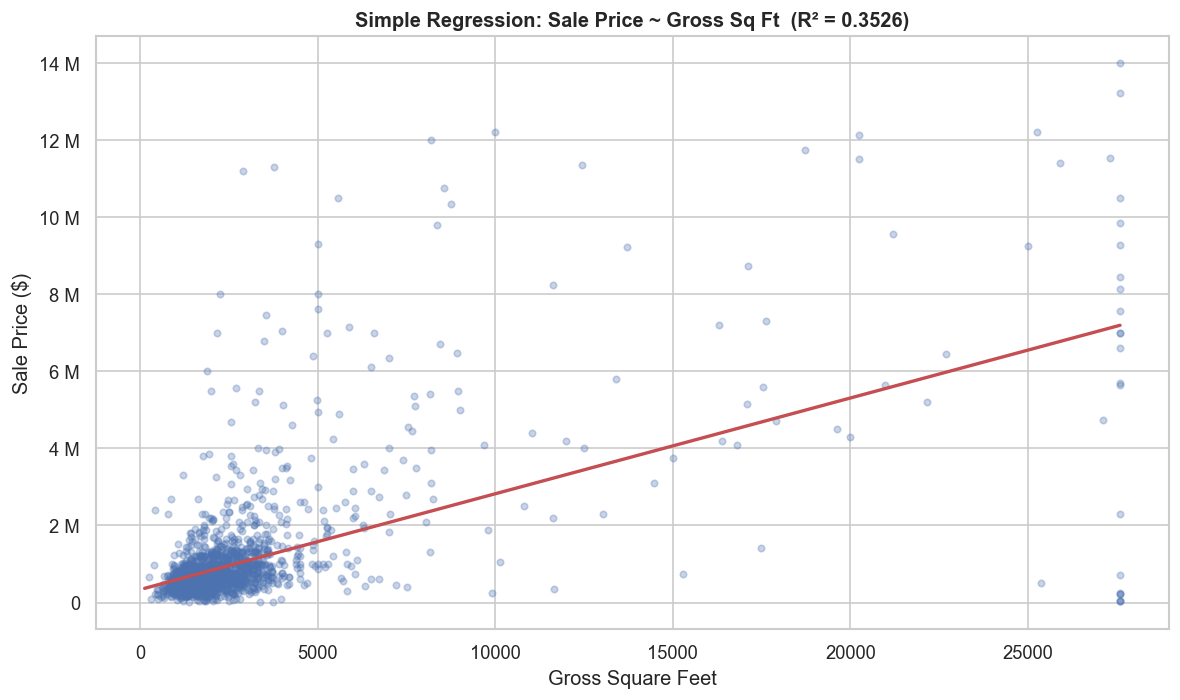

In [8]:
X = analysis_df[['gross_square_feet']].values
y = analysis_df['sale_price'].values

model_simple = LinearRegression().fit(X, y)
y_pred = model_simple.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Intercept:  ${model_simple.intercept_:,.0f}")
print(f"Slope:      ${model_simple.coef_[0]:,.2f} per sq ft")
print(f"R-squared:  {r2:.4f}")
print(f"RMSE:       ${rmse:,.0f}")

# Plot
sample_idx = np.random.choice(len(X), min(2000, len(X)), replace=False)
plt.figure(figsize=(10, 6))
plt.scatter(X[sample_idx], y[sample_idx], alpha=0.3, s=15, color='#4C72B0')
plt.plot(sorted(X[:, 0]), model_simple.predict(np.sort(X, axis=0)), color='#C44E52', lw=2)
plt.xlabel('Gross Square Feet'); plt.ylabel('Sale Price ($)')
plt.title(f'Simple Regression: Sale Price ~ Gross Sq Ft  (R² = {r2:.4f})')
plt.gca().yaxis.set_major_formatter(mtick.EngFormatter())
plt.tight_layout(); plt.show()

> Each additional square foot adds roughly the slope amount to expected price. R² shows size alone explains only a portion of price variance — location, class, and condition are the missing factors.

### 4b. Multiple Linear Regression

In [9]:
feature_cols = ['gross_square_feet', 'building_age', 'residential_units', 'commercial_units']
feature_cols = [c for c in feature_cols if c in analysis_df.columns]

reg_df = analysis_df[feature_cols + ['sale_price']].dropna()
X_multi = reg_df[feature_cols].values
y_multi = reg_df['sale_price'].values

model_multi = LinearRegression().fit(X_multi, y_multi)
y_pred_multi = model_multi.predict(X_multi)
r2_multi = r2_score(y_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_multi, y_pred_multi))
n, p = len(reg_df), len(feature_cols)
adj_r2 = 1 - (1 - r2_multi) * (n - 1) / (n - p - 1)

print(f"Model: sale_price ~ {' + '.join(feature_cols)}")
print(f"\nR-squared:          {r2_multi:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"RMSE:               ${rmse_multi:,.0f}")
print(f"Samples:            {n:,}")
print(f"\nCoefficients:")
print(f"  {'Intercept':<25} ${model_multi.intercept_:>12,.2f}")
for feat, coef in zip(feature_cols, model_multi.coef_):
    print(f"  {feat:<25} {coef:>12,.4f}")

Model: sale_price ~ gross_square_feet + building_age + residential_units + commercial_units

R-squared:          0.3726
Adjusted R-squared: 0.3725
RMSE:               $1,115,723
Samples:            27,943

Coefficients:
  Intercept                 $ -125,961.86
  gross_square_feet             255.9656
  building_age                6,043.1552
  residential_units          -5,290.7938
  commercial_units             -530.9740


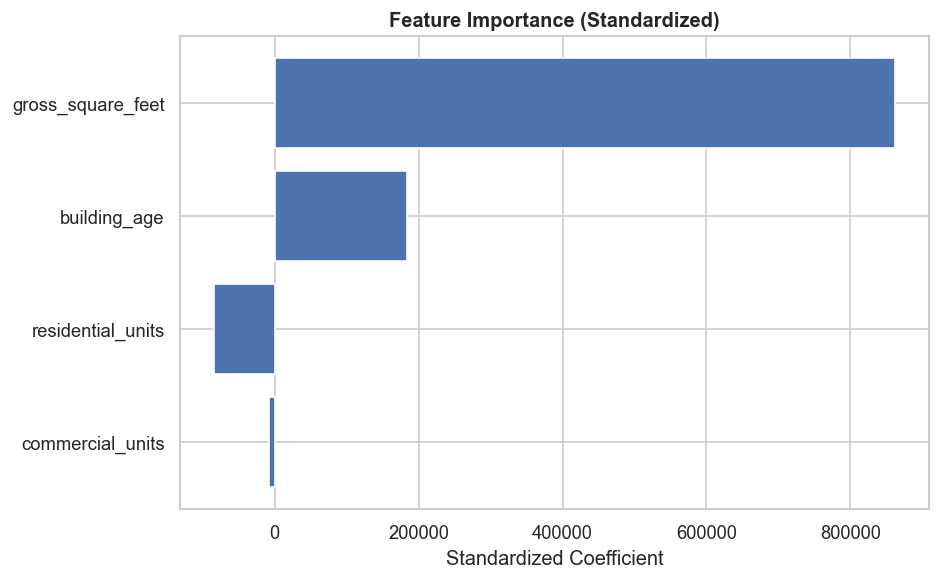

In [10]:
# Standardized coefficients for fair comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)
model_scaled = LinearRegression().fit(X_scaled, y_multi)

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Raw Coefficient': model_multi.coef_,
    'Standardized Coefficient': model_scaled.coef_
}).sort_values('Standardized Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Standardized Coefficient'], color='#4C72B0')
plt.xlabel('Standardized Coefficient'); plt.title('Feature Importance (Standardized)')
plt.tight_layout(); plt.show()

> Adding building age and unit counts improves model fit. `gross_square_feet` dominates feature importance. Commercial units carry disproportionate weight relative to residential ones — commercial space is far more valuable per unit.

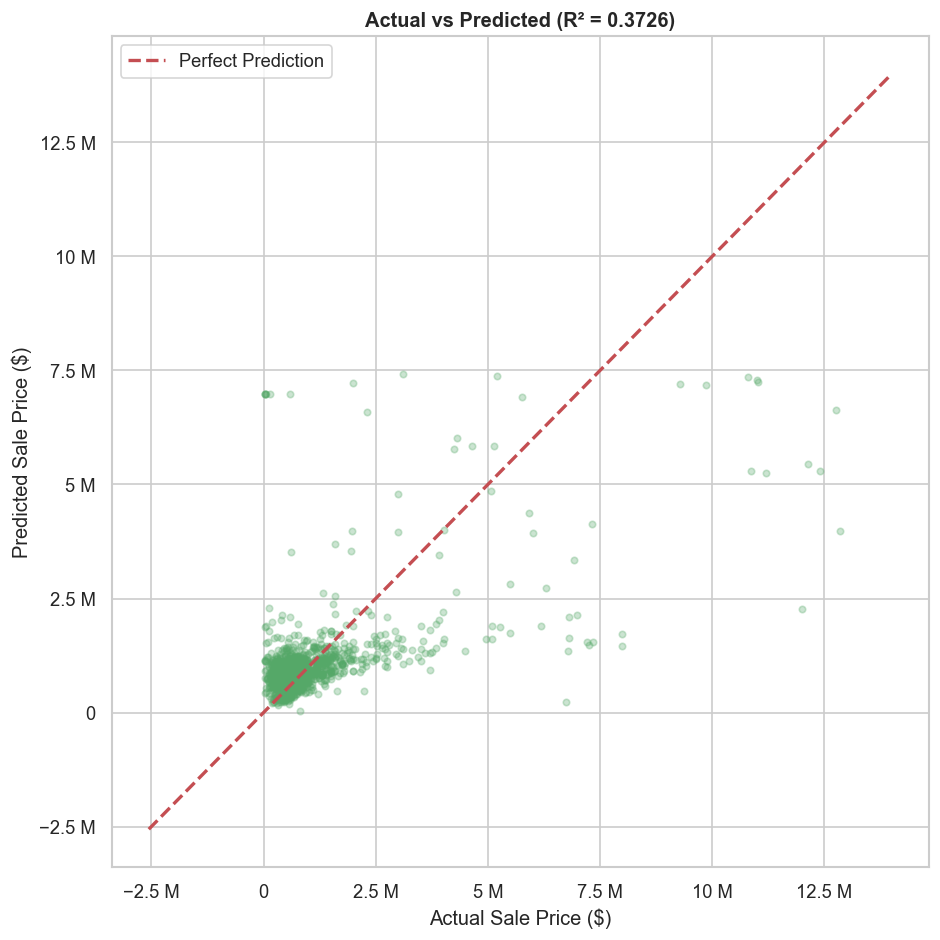

In [11]:
# Actual vs Predicted
sample_idx = np.random.choice(len(reg_df), min(1500, len(reg_df)), replace=False)
plt.figure(figsize=(8, 8))
plt.scatter(y_multi[sample_idx], y_pred_multi[sample_idx], alpha=0.3, s=15, color='#55A868')
lims = [min(y_multi.min(), y_pred_multi.min()), max(y_multi.max(), y_pred_multi.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sale Price ($)'); plt.ylabel('Predicted Sale Price ($)')
plt.title(f'Actual vs Predicted (R² = {r2_multi:.4f})')
plt.gca().xaxis.set_major_formatter(mtick.EngFormatter())
plt.gca().yaxis.set_major_formatter(mtick.EngFormatter())
plt.legend(); plt.tight_layout(); plt.show()

> The model underpredicts high-value properties — the scatter fans out above the diagonal. This confirms that size-based features alone can't capture location/class premiums. A segmented or ensemble model is needed for production use.

## 5 · Key Statistical Conclusions

1. **Location is the #1 price driver** — ANOVA confirms boroughs have significantly different mean prices (p ≈ 0). Manhattan commands 2–3× the price of outer boroughs.

2. **Size scales linearly but explains limited variance** — `gross_square_feet` is the strongest single predictor but R² remains moderate. Size is necessary but not sufficient.

3. **Commercial ≠ Residential** — T-test confirms a statistically significant price gap. Models must treat them separately or include property type controls.

4. **Building class predicts price tier** — Chi-square test shows building classification and price bracket are not independent. Useful as a categorical feature.

5. **Age is not a simple depreciator** — Near-zero linear correlation with price. Pre-war buildings retain premium value. Age should be binned or modeled non-linearly.

6. **Multi-feature regression improves but doesn't solve** — Adding features beyond sqft improves R², but the model still struggles with luxury outliers. Borough-level segmented models or tree-based approaches are the logical next step.

7. **Engineered features validate well** — `price_per_sqft`, `price_per_unit`, and `floor_area_ratio` all show expected correlations and add analytical value beyond raw columns.